# 00. Start here: Python and Sage for physicists

This notebook is for someone who has never written a program, or who only knows `print("hello world")`.
In half an hour it teaches everything the other feynsage notebooks need. Nothing here is about Feynman
diagrams yet.

**How to use a notebook.** A notebook is a list of boxes called *cells*. A grey box is a *code cell*.
Click on it and press **Shift + Enter**: the computer runs the code and shows the answer just below.
A white box like this one is only text. Run the cells from top to bottom, one by one, because a later
cell may use something made in an earlier one. If something goes strange, use the menu *Kernel → Restart*
and run the cells again from the top.

The notebooks of feynsage, in order:

| Notebook | What it teaches |
|---|---|
| `00_start_here.ipynb` | Python and Sage, from zero (this one) |
| `01_qft_tree_level.ipynb` | Feynman diagrams at tree level: traces, \|M\|², cross sections and decay widths |
| `02_qft_one_loop.ipynb` | loops: A0, B0, C0, D0, renormalization, running couplings, g − 2, H → γγ, virtual corrections |
| `03_lecture_note_feynman_integrals.ipynb` | the lecture note *Feynman integrals at one loop* of Prof. B. Ananthanarayan (NISER, 2026), with feynsage |
| `04_feynsage_toolbox.ipynb` | graphs, Symanzik polynomials, integration by parts, master integrals, differential equations and more |

## 1. Printing

`print(...)` shows what is inside the brackets. Text goes inside quotes.

In [1]:
print("hello world")
print("the electron mass is", 0.000511, "GeV")

hello world
the electron mass is 0.000511000000000000 GeV


## 2. Variables: giving a name to a value

The sign `=` means "store the value on the right under the name on the left". It is not the `=` of
mathematics. After that, the name can be used in place of the value.

In [2]:
m_e = 0.000511          # GeV.  Everything after # is a comment: the computer ignores it
m_mu = 0.10566
ratio = m_mu / m_e
print("m_mu / m_e =", ratio)

m_mu / m_e = 206.771037181996


In Sage, `^` means "to the power" (in plain Python it would be `**`; Sage accepts both).

In [3]:
print(2^10, 2**10)
print(m_mu^2)

1024 1024
0.0111640356000000


## 3. Lists and loops

A *list* is a row of values inside square brackets. A `for` loop takes the values of a list one by one.
The lines that belong to the loop are pushed to the right by four spaces; that is how Python knows
where the loop ends.

In [4]:
leptons = ["e", "mu", "tau"]
masses = [0.000511, 0.10566, 1.77686]

for m in masses:
    print("mass:", m, "GeV   mass squared:", m^2)

mass: 0.000511000000000000 GeV   mass squared: 2.61121000000000e-7
mass: 0.105660000000000 GeV   mass squared: 0.0111640356000000
mass: 1.77686000000000 GeV   mass squared: 3.15723145960000


`zip` walks through two lists side by side, and `range(n)` gives the numbers 0, 1, ..., n − 1.

In [5]:
for name, m in zip(leptons, masses):
    print(name, "has mass", m, "GeV")

for k in range(4):
    print("k =", k, " 2^k =", 2^k)

e has mass 0.000511000000000000 GeV
mu has mass 0.105660000000000 GeV
tau has mass 1.77686000000000 GeV
k = 0  2^k = 1
k = 1  2^k = 2
k = 2  2^k = 4
k = 3  2^k = 8


## 4. Functions: a recipe with a name

`def` makes a new function. The values it needs go in the brackets, and `return` says what it gives back.
Here is the Källén function, which appears in every two-body decay:
λ(a, b, c) = a² + b² + c² − 2ab − 2ac − 2bc.

In [6]:
def kallen(a, b, c):
    return a^2 + b^2 + c^2 - 2*a*b - 2*a*c - 2*b*c

print(kallen(100, 1, 4))

9009


## 5. Dictionaries: a small table

A *dictionary* stores pairs `key: value` inside curly brackets. You look up a value with its key.
feynsage uses dictionaries for kinematics, for example `{"p^2": "s"}` means "p² is s".

In [7]:
mass = {"e": 0.000511, "mu": 0.10566, "tau": 1.77686}
print(mass["mu"])

for name in mass:
    print(name, mass[name])

0.105660000000000
e 0.000511000000000000
mu 0.105660000000000
tau 1.77686000000000


## 6. Symbols: algebra like Mathematica

This is where Sage is more than Python. `var` makes symbols, and with them you can do algebra exactly,
as on paper. The last line of a cell is shown nicely by itself, without `print`.

In [8]:
s, t, u, m = var('s t u m')
expr = (s + t)^2
expr

(s + t)^2

In [9]:
expr.expand()

s^2 + 2*s*t + t^2

Some commands that make a result short and clean, like `Simplify`, `Factor` and `Collect` in Mathematica:

| Sage | What it does |
|---|---|
| `e.expand()` | multiplies everything out |
| `e.factor()` | writes it as a product |
| `e.simplify_full()` | simplifies (also fractions, powers and logarithms) |
| `e.collect(x)` | collects the powers of x |
| `e.subs(x=2)` | puts in a value |
| `e.n()` or `e.n(digits=30)` | the numerical value |

In [10]:
f = (s^2 - t^2)/(s - t)
f.simplify_full()

s + t

In [11]:
g = s^2*t + 2*s*t^2 + s*t + t^3
show(g.factor())
show(g.collect(t))

(s^2 + 2*s*t + t^2 + s)*t

2*s*t^2 + t^3 + (s^2 + s)*t

In [12]:
h = 2*(t^2 + u^2)/s^2
h.subs(s=100, t=-30, u=-70)

29/25

`show(...)` prints a formula in typeset form, as in a book. Numbers can be as precise as you like:

In [13]:
print(pi.n(digits=40))
print(sqrt(2).n(digits=40))

3.141592653589793238462643383279502884197
1.414213562373095048801688724209698078570


## 7. Calculus

Derivatives, integrals and series are exact when possible.

In [14]:
x = var('x')
show(diff(x^2*sin(x), x))
show(integrate(1/(1 + x^2), x, 0, 1))
show(taylor(exp(x), x, 0, 4))

x^2*cos(x) + 2*x*sin(x)

1/4*pi

1/24*x^4 + 1/6*x^3 + 1/2*x^2 + x + 1

An integral that has no closed form is done numerically with `numerical_integral`. It gives the value and
an estimate of the error.

In [15]:
numerical_integral(exp(-x^2)*cos(x), 0, 10)

(0.6901942235215717, 7.785975963152384e-15)

## 8. Complex numbers

`I` is the imaginary unit. Loop integrals are often complex, so this will come up.

In [16]:
z = (1 + I)^2
print(z, abs(z), z.real(), z.imag())
print(log(-1))

2*I 2 0 2
I*pi


## 9. Plots

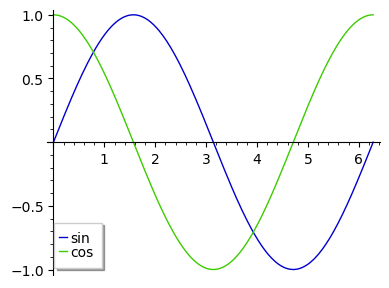

In [17]:
plot([sin(x), cos(x)], (x, 0, 2*pi), legend_label=["sin", "cos"], figsize=4)

## 10. Loading feynsage and asking for help

One line loads everything. `info(...)` prints what a function does, and `name?` (a question mark after a
name) shows its documentation in the notebook.

In [18]:
from feynsage import *
info(process)

process
-------
process("e- e+ -> mu- mu+"): see feynsage.process.


A first taste of what is coming: the squared amplitude of e⁺e⁻ → μ⁺μ⁻ in QED, summed over spins and
averaged over the spins of the electron and positron, with the masses set to zero.

In [19]:
P = process("e- e+ -> mu- mu+", model="QED", massless=["e", "mu"])
P.squared().factor()

2*(t^2 + u^2)*EL^4/s^2

That is 2e⁴(t² + u²)/s², the textbook result. The next notebook explains every step of it.

## 11. When something goes wrong

An error message looks long, but read its **last line** first: it says what went wrong. Common mistakes:

- a name used before the cell that makes it was run: run the cells from the top;
- forgetting the `*` in a product: write `2*s`, not `2s`;
- forgetting quotes around text: `process("e- e+ -> mu- mu+")`, not `process(e- e+ -> mu- mu+)`;
- wrong indentation inside a `for` loop or a `def`.

## 12. Exercises

1. Make a list of the three quark masses (u, c, t) and print each mass squared with a `for` loop.
2. Write a function `beta(s, m)` that returns √(1 − 4m²/s), the speed of a pair of particles of mass m.
   Print it for s = 100 and m = 1, 2, 3.
3. With `var('a b')`, expand (a + b)⁵ and then factor the result back.